# Perhitungan Volume Kedua Lambung Perahu

Nama        : Dhea Alya Afkarina

NPM         : 25083010018

Kelas       : A - Analisis Numerik

## Landasan Perhitungan

Karena penampang melintang berupa persegi panjang, luas penampang di posisi $x$ adalah hasil kali lebar lambung $b(x)$ (dari tampak atas) dan tinggi lambung $h(x)$ (dari tampak samping):

$$A(x) = b(x)\,h(x)$$

Volume lambung adalah integral luas penampang sepanjang lambung:

$$V = \int_{0}^{L} A(x)\,dx$$

Nilai $A(x)$ hanya diketahui pada titik-titik hasil pengukuran, sehingga integral dihampiri secara numerik. Panjang lambung dibagi menjadi $n$ interval sama panjang, $\Delta x = L/n$, dengan titik $x_i = i\,\Delta x$ dan $A_i = A(x_i)$.

**Aturan Simpson 1/3** (syarat: $n$ genap)

$$V \approx \frac{\Delta x}{3}\Big[A_0 + 4\sum_{i\ \text{ganjil}} A_i + 2\sum_{i\ \text{genap}} A_i + A_n\Big]$$

**Aturan trapesium** (sebagai pembanding)

$$V \approx \frac{\Delta x}{2}\Big[A_0 + 2\sum_{i=1}^{n-1} A_i + A_n\Big]$$

Galat Simpson 1/3 berorde $\Delta x^4$, sedangkan trapesium berorde $\Delta x^2$. Oleh karena itu Simpson 1/3 dipakai sebagai hasil utama. Taksiran galatnya diperoleh dengan membandingkan hasil $n$ dan $n/2$ interval:

$$E_{S} \approx \frac{S_{n} - S_{n/2}}{15}$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Skala Gambar

Satu dash-kosong bernilai 5 + 5 = 10 cm, dan satu kotak grid diambil sebesar dua dash-kosong, yaitu **0,20 m**. Nilai ini dapat dicocokkan dengan sumber gambar (Yuwandana dkk., 2013): grid selebar 20 kotak setara 4 m, sama dengan panjang perahu yang dilaporkan pada publikasi tersebut.

Gambar PDF dirender pada 300 dpi dan seluruh pengukuran dibaca dalam piksel. Jarak satu kotak diperoleh dari rata-rata selisih posisi 21 garis grid vertikal.

In [ ]:
# posisi garis grid vertikal pada gambar (piksel, render 300 dpi)
garis_grid = np.array([89.0, 194.5, 301.5, 408.5, 515.5, 621.5, 728.5, 835.5, 943.0, 1050.0, 1157.0, 1264.0, 1371.0, 1477.5, 1584.5, 1691.5, 1798.5, 1905.5, 2012.5, 2119.5, 2225.0])

px_per_kotak = np.diff(garis_grid).mean()
m_per_kotak = 0.20
px_per_m = px_per_kotak / m_per_kotak

print(f"Jarak satu kotak grid : {px_per_kotak:.1f} px")
print(f"Skala                 : {px_per_m:.1f} px/m  (1 px = {1000/px_per_m:.3f} mm)")
print(f"Lebar seluruh grid    : {20*m_per_kotak:.1f} m")

Jarak satu kotak grid : 106.8 px
Skala                 : 534.0 px/m  (1 px = 1.873 mm)
Lebar seluruh grid    : 4.0 m


## Batas Lambung dan Pembagian Interval

*Reserve buoyancy* terletak di luar sekat (garis lengkung tipis) pada ujung buritan dan ujung haluan, sehingga integrasi hanya dilakukan di antara kedua sekat tersebut. Panjang efektif lambung dibagi menjadi $n = 32$ interval (genap, sehingga Simpson 1/3 dapat dipakai).

In [ ]:
x_sekat_buritan = 294.5     # px
x_sekat_haluan  = 2018.0    # px
n = 32

L = (x_sekat_haluan - x_sekat_buritan) / px_per_m
dx = L / n
x = np.arange(n + 1) * dx

assert n % 2 == 0
print(f"Panjang efektif lambung L = {L:.4f} m")
print(f"Jarak antartitik      dx = {dx:.4f} m  ({n + 1} titik)")

Panjang efektif lambung L = 3.2275 m
Jarak antartitik      dx = 0.1009 m  (33 titik)


## Data Pengukuran

Pengukuran dilakukan pada 33 titik yang jaraknya sama:

- **Lebar** $b_i$ dibaca pada tampak atas, yaitu jarak antara pusat garis tepi luar sisi atas dan sisi bawah lambung. Kedua lambung diukur terpisah.
- **Tinggi** $h_i$ dibaca pada tampak samping, yaitu jarak dari pusat garis bawah dek (garis sheer) sampai pusat garis dasar lambung. Karena lantai datar dan kedua lambung identik pada tampak samping, satu profil tinggi dipakai untuk kedua lambung.
- Pada titik ke-4 dan ke-23, garis tepi lambung tertutup penopang melintang sehingga tidak dapat dibaca. Nilai lebar pada kedua titik ini (`nan`) diisi dengan interpolasi linear dari titik tetangganya.

In [ ]:
# hasil pengukuran dalam piksel
lebar1_px = np.array([
    182.0, 192.0, 200.0, 207.5, np.nan, 216.0, 219.5, 221.5, 222.5, 222.5, 222.5,
    222.0, 222.5, 222.5, 222.5, 223.0, 222.5, 223.0, 223.0, 223.5, 224.0, 223.5,
    222.0, np.nan, 218.0, 214.0, 208.0, 202.0, 192.0, 181.5, 168.0, 153.5, 136.0
])

lebar2_px = np.array([
    182.0, 191.5, 200.0, 207.0, np.nan, 216.0, 219.5, 222.0, 222.5, 223.0, 223.0,
    223.0, 223.0, 222.5, 223.0, 223.5, 223.5, 224.0, 223.5, 224.0, 224.0, 223.5,
    222.0, np.nan, 218.0, 214.0, 208.0, 201.0, 192.0, 181.5, 168.0, 153.5, 136.0
])

tinggi_px = np.array([
    183.0, 204.5, 223.0, 239.5, 253.0, 263.0, 263.0, 263.0, 263.0, 263.0, 262.5,
    262.5, 262.0, 262.5, 262.0, 262.0, 262.0, 262.0, 262.0, 262.0, 262.0, 261.0,
    261.0, 261.0, 261.0, 261.0, 261.0, 261.0, 261.0, 261.0, 261.0, 261.0, 261.0
])

In [ ]:
def isi_kosong(a):
    # interpolasi linear untuk titik yang tidak terbaca (nan)
    idx = np.arange(len(a))
    ada = ~np.isnan(a)
    return np.interp(idx, idx[ada], a[ada])

b1 = isi_kosong(lebar1_px) / px_per_m     # lebar lambung 1 (m)
b2 = isi_kosong(lebar2_px) / px_per_m     # lebar lambung 2 (m)
h  = tinggi_px / px_per_m                 # tinggi lambung (m)

assert len(x) == len(b1) == len(b2) == len(h)
print("Titik tanpa data lebar (diinterpolasi):",
      np.where(np.isnan(lebar1_px))[0].tolist())
print(f"Selisih lebar maksimum antara lambung 1 dan 2: {np.abs(b1 - b2).max()*100:.2f} cm")

Titik tanpa data lebar (diinterpolasi): [4, 23]
Selisih lebar maksimum antara lambung 1 dan 2: 0.19 cm


## Luas Penampang

Luas penampang tiap titik dihitung dengan $A_i = b_i\,h_i$.

In [ ]:
A1 = b1 * h
A2 = b2 * h

tabel = pd.DataFrame({
    "i": np.arange(n + 1),
    "x (m)": x,
    "b1 (m)": b1,
    "b2 (m)": b2,
    "h (m)": h,
    "A1 (m²)": A1,
    "A2 (m²)": A2,
}).set_index("i")

tabel.round(4)

,x (m),b1 (m),b2 (m),h (m),A1 (m²),A2 (m²)
i,,,,,,
0,0.0000,0.3408,0.3408,0.3427,0.1168,0.1168
1,0.1009,0.3596,0.3586,0.3830,0.1377,0.1373
2,0.2017,0.3745,0.3745,0.4176,0.1564,0.1564
3,0.3026,0.3886,0.3876,0.4485,0.1743,0.1739
4,0.4034,0.3965,0.3961,0.4738,0.1879,0.1876
5,0.5043,0.4045,0.4045,0.4925,0.1992,0.1992
6,0.6052,0.4110,0.4110,0.4925,0.2024,0.2024
7,0.7060,0.4148,0.4157,0.4925,0.2043,0.2048
8,0.8069,0.4167,0.4167,0.4925,0.2052,0.2052


## Integrasi Numerik

Kedua aturan ditulis dalam bentuk jumlah berbobot, $V = c\,\Delta x \sum w_i A_i$. Pola bobot Simpson 1/3 adalah $1,4,2,4,\dots,4,1$, sedangkan bobot trapesium adalah $1,2,2,\dots,2,1$.

Sebelum dipakai pada data perahu, fungsi diuji pada $A(x) = x^2$, yang integralnya diketahui secara eksak, yaitu $L^3/3$. Simpson 1/3 seharusnya tepat untuk polinom sampai derajat tiga.

In [ ]:
def bobot_simpson(n):
    w = np.ones(n + 1)
    w[1:-1:2] = 4
    w[2:-1:2] = 2
    return w

def bobot_trapesium(n):
    w = np.full(n + 1, 2.0)
    w[[0, -1]] = 1
    return w

def simpson_13(A, dx):
    n = len(A) - 1
    if n % 2:
        raise ValueError("Simpson 1/3 memerlukan jumlah interval genap")
    return dx / 3 * np.dot(bobot_simpson(n), A)

def trapesium(A, dx):
    n = len(A) - 1
    return dx / 2 * np.dot(bobot_trapesium(n), A)

# uji fungsi pada A(x) = x^2
eksak = L**3 / 3
print(f"Eksak     : {eksak:.6f}")
print(f"Simpson   : {simpson_13(x**2, dx):.6f}")
print(f"Trapesium : {trapesium(x**2, dx):.6f}")

Eksak     : 11.206986
Simpson   : 11.206986
Trapesium : 11.212458


## Hasil Perhitungan

In [ ]:
V1_s, V2_s = simpson_13(A1, dx), simpson_13(A2, dx)
V1_t, V2_t = trapesium(A1, dx), trapesium(A2, dx)

hasil = pd.DataFrame({
    "Lambung 1 (m³)": [V1_s, V1_t],
    "Lambung 2 (m³)": [V2_s, V2_t],
    "Total (m³)":     [V1_s + V2_s, V1_t + V2_t],
}, index=["Simpson 1/3", "Trapesium"])
hasil["Total (liter)"] = hasil["Total (m³)"] * 1000

hasil.round(4)

,Lambung 1 (m³),Lambung 2 (m³),Total (m³),Total (liter)
Simpson 1/3,0.6119,0.6124,1.2243,1224.2952
Trapesium,0.6114,0.6119,1.2234,1223.3511


In [ ]:
V_total = V1_s + V2_s
beda = abs(V1_s + V2_s - (V1_t + V2_t)) / V_total * 100

print(f"Volume lambung 1 = {V1_s:.4f} m³")
print(f"Volume lambung 2 = {V2_s:.4f} m³")
print(f"Volume total     = {V_total:.4f} m³  (≈ {V_total*1000:,.0f} liter)".replace(",", "."))
print(f"Selisih Simpson dan trapesium = {beda:.2f} %")

Volume lambung 1 = 0.6119 m³
Volume lambung 2 = 0.6124 m³
Volume total     = 1.2243 m³  (≈ 1.224 liter)
Selisih Simpson dan trapesium = 0.08 %


## Pemeriksaan Hasil

### Konvergensi

Hasil Simpson dengan n = 32 dibandingkan dengan n = 16 (memakai setiap titik kedua). Selisihnya dipakai untuk menaksir galat pemotongan.

In [ ]:
rincian = []
for nama, A, S32 in [("Lambung 1", A1, V1_s), ("Lambung 2", A2, V2_s)]:
    S16 = simpson_13(A[::2], 2 * dx)
    galat = (S32 - S16) / 15
    rincian.append([nama, S16, S32, galat, abs(galat) / S32 * 100])

pd.DataFrame(rincian, columns=["Lambung", "S (n=16)", "S (n=32)",
                               "Taksiran galat (m³)", "Galat relatif (%)"]).round(6)

,Lambung,S (n=16),S (n=32),Taksiran galat (m³),Galat relatif (%)
0,Lambung 1,0.611125,0.611929,0.000054,0.008759
1,Lambung 2,0.611651,0.612366,0.000048,0.007786


### Pengaruh skala dan ketelitian pembacaan

Volume sebanding dengan pangkat tiga skala, sehingga kesalahan skala lebih berpengaruh daripada kesalahan baca. Kesalahan baca diuji dengan menambah atau mengurangi 3 px (±5,6 mm) pada lebar dan tinggi sekaligus.

In [ ]:
def volume_total(skala=1.0, d_px=0.0):
    pm = px_per_m * skala
    bb1 = (isi_kosong(lebar1_px) + d_px) / pm
    bb2 = (isi_kosong(lebar2_px) + d_px) / pm
    hh  = (tinggi_px + d_px) / pm
    dxx = (x_sekat_haluan - x_sekat_buritan) / pm / n
    return simpson_13(bb1 * hh, dxx) + simpson_13(bb2 * hh, dxx)

kasus = [("Dasar (tanpa perubahan)", 1.00, 0),
         ("Skala px/m +1 %",          1.01, 0),
         ("Skala px/m -1 %",          0.99, 0),
         ("Lebar dan tinggi +3 px",   1.00, 3),
         ("Lebar dan tinggi -3 px",   1.00, -3)]

uji = pd.DataFrame(
    [[k, volume_total(s, d), (volume_total(s, d) / V_total - 1) * 100] for k, s, d in kasus],
    columns=["Kasus", "Volume total (m³)", "Perubahan (%)"])
uji.round(4)

,Kasus,Volume total (m³),Perubahan (%)
0,Dasar (tanpa perubahan),1.2243,0.0000
1,Skala px/m +1 %,1.1883,-2.9410
2,Skala px/m -1 %,1.2618,3.0610
3,Lebar dan tinggi +3 px,1.2562,2.6074
4,Lebar dan tinggi -3 px,1.1928,-2.5741


### Kesesuaian dengan dimensi sumber

Dimensi pada publikasi sumber dipakai sebagai pembanding kasar: lebar satu lambung 0,40 m (rasio panjang/lebar satu lambung = 10 untuk panjang 4 m), dalam perahu 0,55 m, dan jarak antar lambung 1 m.

In [ ]:
tengah = slice(8, 25)    # bagian lambung dengan lebar dan tinggi hampir konstan
print(f"Lebar rata-rata bagian tengah : {np.r_[b1[tengah], b2[tengah]].mean():.3f} m  (sumber: 0,40 m)")
print(f"Tinggi bagian tengah          : {h[tengah].mean():.3f} m  (sumber: dalam 0,55 m)")

# jarak antar lambung: pusat garis tepi luar bawah lambung 1 ke pusat garis tepi luar atas lambung 2 (x = 1000 px)
jarak_antar = (979.0 - 429.0) / px_per_m
print(f"Jarak antar lambung           : {jarak_antar:.3f} m  (sumber: 1 m)")

Lebar rata-rata bagian tengah : 0.417 m  (sumber: 0,40 m)
Tinggi bagian tengah          : 0.491 m  (sumber: dalam 0,55 m)
Jarak antar lambung           : 1.030 m  (sumber: 1 m)


Lebar hasil pengukuran berbeda sekitar 4 % dari nilai sumber dan jarak antar lambung hanya berbeda sekitar 3 %, sehingga skala 0,20 m per kotak dinilai sesuai. Tinggi hasil pengukuran lebih kecil sekitar 11 %, kemungkinan karena dibaca dari garis bawah dek (sedangkan dalam perahu pada sumber dapat mencakup ketebalan dek) dan karena sketsa tidak sepenuhnya berskala. Selisih ini masih wajar untuk pembacaan dari gambar.

## Visualisasi

Bentuk lambung direkonstruksi dari data ukur sebagai pemeriksaan visual: tampak atas dari lebar, tampak samping dari tinggi, dan distribusi luas penampang di sepanjang lambung.

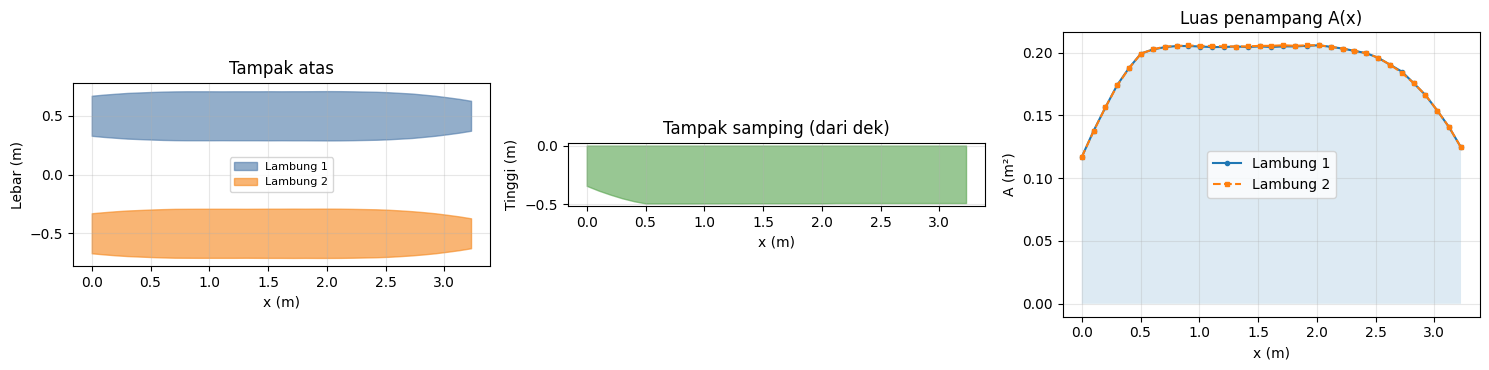

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))

# tampak atas (lambung 1 dan 2 digambar simetris terhadap sumbu masing-masing)
ax[0].fill_between(x,  b1 / 2 + 0.5,  -b1 / 2 + 0.5, color="#4C78A8", alpha=0.6, label="Lambung 1")
ax[0].fill_between(x,  b2 / 2 - 0.5,  -b2 / 2 - 0.5, color="#F58518", alpha=0.6, label="Lambung 2")
ax[0].set_title("Tampak atas")
ax[0].set_ylabel("Lebar (m)")
ax[0].set_aspect("equal")

# tampak samping
ax[1].fill_between(x, 0, -h, color="#54A24B", alpha=0.6)
ax[1].set_title("Tampak samping (dari dek)")
ax[1].set_ylabel("Tinggi (m)")
ax[1].set_aspect("equal")

# luas penampang
ax[2].plot(x, A1, "o-", ms=3, label="Lambung 1")
ax[2].plot(x, A2, "s--", ms=3, label="Lambung 2")
ax[2].fill_between(x, A1, alpha=0.15)
ax[2].set_title("Luas penampang A(x)")
ax[2].set_ylabel("A (m²)")

for a in ax:
    a.set_xlabel("x (m)")
    a.grid(alpha=0.3)
ax[0].legend(loc="center", fontsize=8)
ax[2].legend()
plt.tight_layout()
plt.show()

## Kesimpulan

Volume kedua lambung dihitung dengan integrasi numerik Simpson 1/3 terhadap luas penampang $A(x) = b(x)\,h(x)$ pada 33 titik di antara kedua sekat (tanpa *reserve buoyancy*), dengan skala satu kotak grid = 0,20 m. Hasilnya:

| Besaran | Nilai |
|---|---|
| Volume lambung 1 | ≈ 0,612 m³ |
| Volume lambung 2 | ≈ 0,612 m³ |
| **Volume kedua lambung** | **≈ 1,224 m³** (≈ 1.224 liter) |